# Model Evaluation

Our final model: resnet50, layer4 unfrozen, trained with augmentation.

Let's see how well does it performs.

In [38]:
import torch
from torch import nn

from torchvision import datasets
import torchvision
from torch.utils.data import DataLoader

In [39]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [40]:
def create_resnet50(num_classes: int=37):
    weights = torchvision.models.ResNet50_Weights.DEFAULT
    transform = weights.transforms()
    model = torchvision.models.resnet50(weights=weights)

    for param in model.parameters():
        param.requires_grad = False

    model.fc = nn.Linear(in_features=2048, out_features=num_classes, bias=True)

    return model, transform

In [41]:
from going_modular import utils
resnet50, resnet50_transforms = create_resnet50()
resnet50 = utils.load_model(resnet50, 'models/resnet_50_unfrozen_layer4_and_manual_transform.pth', device=device)

In [42]:
from going_modular import data_setup

test_data = datasets.OxfordIIITPet(root='data', split='test', transform=resnet50_transforms, download=True)
resnet50_test_dataloader = DataLoader(test_data, batch_size=32, shuffle=False)

In [43]:
class_names = test_data.classes

Let's test the predictions on the test dataloader.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.3959913].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9656862..2.3935575].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0665298..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9124069..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.980906..2.2391288].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping 

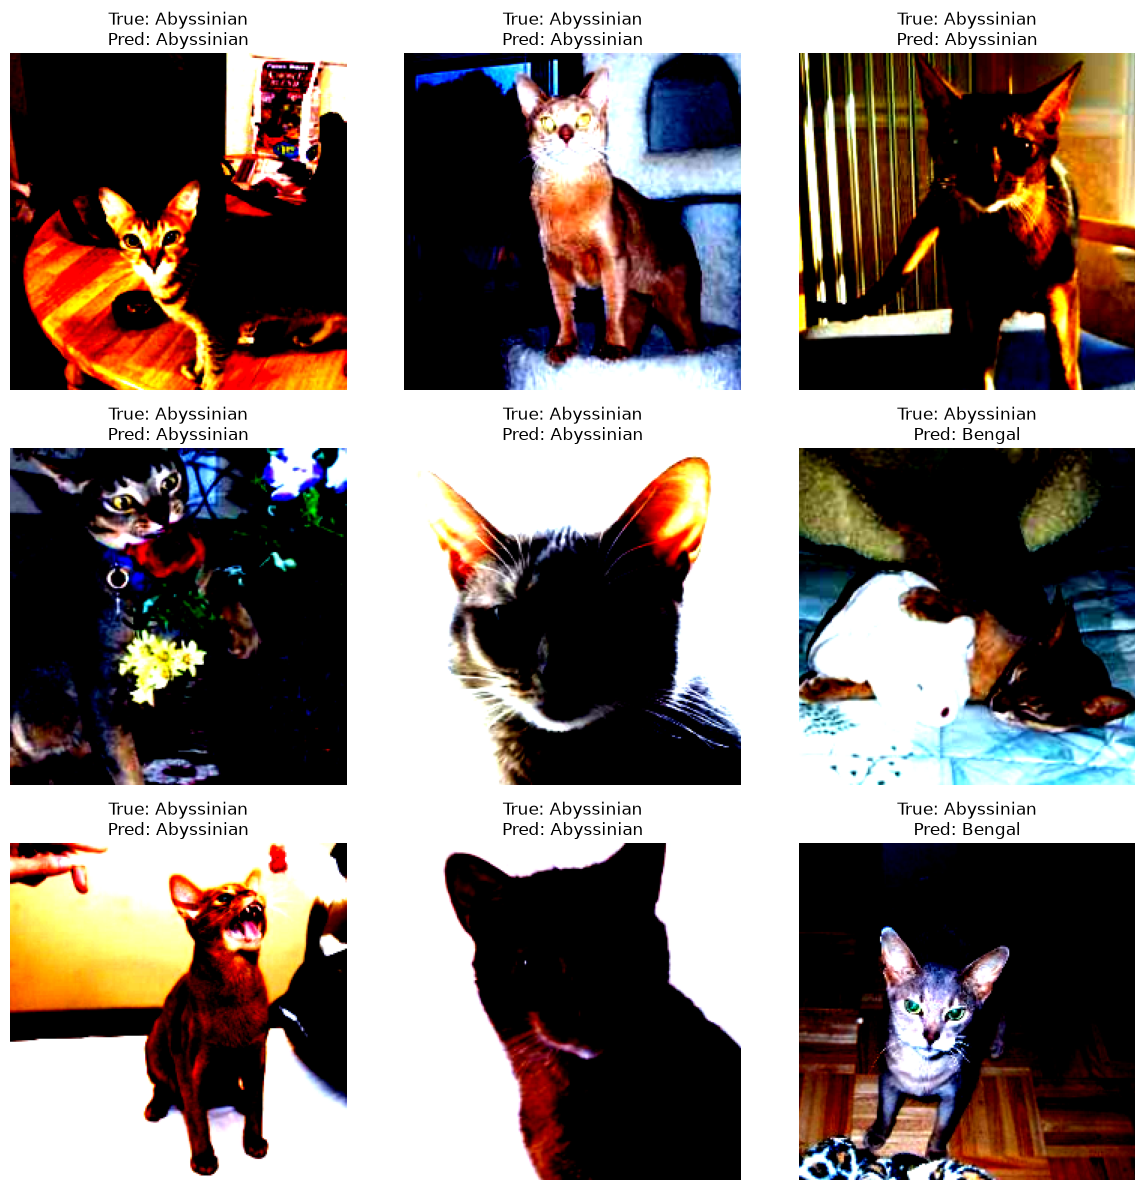

In [44]:
import matplotlib.pyplot as plt

resnet50.eval()

images, labels = next(iter(resnet50_test_dataloader))
images, labels = images.to(device), labels.to(device)

with torch.inference_mode():
    preds = resnet50(images).argmax(dim=1)

plt.figure(figsize=(12, 12))
for i in range(9):
    img = images[i].cpu().permute(1, 2, 0) 
    
    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.title(f"True: {class_names[labels[i]]}\nPred: {class_names[preds[i]]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

Now let's create a function to make predictions on custom images.

In [45]:
from PIL import Image
def predict_image(image_path, model=resnet50, transform=resnet50_transforms):
    img = Image.open(image_path)

    model.eval()
    with torch.inference_mode():
        img_tensor = transform(img).unsqueeze(0).to(device)   # Added batch dimension
        pred = model(img_tensor).argmax(dim=1)

    plt.imshow(img)
    plt.title(f"Pred: {class_names[pred]}")
    plt.axis("off")
    plt.show()

I have downloaded two images of bengal cat, one is pretty clear and one is not so clear. Let's make predictions on them.

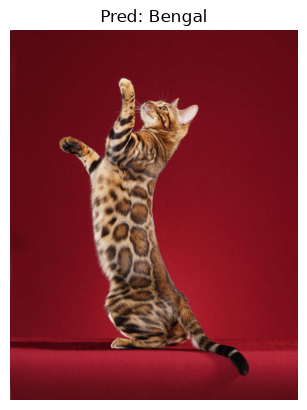

In [46]:
img_path = 'custom_images/bengal_cat.jpg'
predict_image(img_path)

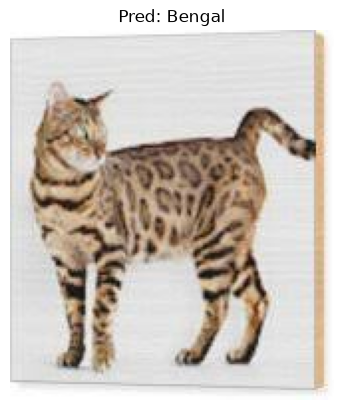

In [47]:
img_path = 'custom_images/bengal_cat_bad_pixels.jpeg'
predict_image(img_path)

Yeah I know, the image is not so bad. But I couldn't find a bad one(or didn't want to find one). Let's try some other breed too.

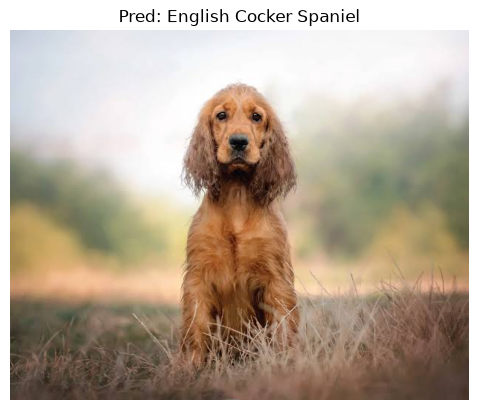

In [49]:
img_path = 'custom_images/english_cocker_spaniel.jpeg'
predict_image(img_path)

Heck yeahh..it's working ok for clear images...but of course it's not that great. Let's deploy the model.